In [1]:
from google.colab import drive
from google.colab import output
import os

drive.mount('/content/drive')

notebook_name = 'Demand_Forecasting_EDA_Pipeline.ipynb'
notebook_path = os.path.join('/content/drive/MyDrive/Ai demand restaurnat and wastage forcasring', notebook_name)


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# ==============================
# 🚀 WEEK 1: DEMAND FORECASTING - EDA PIPELINE
# ==============================

# ==============================
# 📦 INSTALL & IMPORTS
# ==============================
!pip install -q kagglehub plotly statsmodels seaborn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

# ==============================
# 📂 LOAD DATA
# ==============================
path = kagglehub.dataset_download("kannanaikkal/food-demand-forecasting")
print("Dataset path:", path)

import os
files = os.listdir(path)
print("Files:", files)

# Load main dataset (adjust if needed)
df = pd.read_csv(os.path.join(path, "train.csv"))

print("\nDataset Shape:", df.shape)
df.head()

Dataset path: C:\Users\SATHVIK\.cache\kagglehub\datasets\kannanaikkal\food-demand-forecasting\versions\1
Files: ['fulfilment_center_info.csv', 'meal_info.csv', 'sample_submission.csv', 'test.csv', 'train.csv']

Dataset Shape: (456548, 9)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [2]:
# ==============================
# 🧹 DATA CLEANING
# ==============================

df.info()

# Convert date
df['week'] = pd.to_datetime(df['week'])

# Rename for clarity
df.rename(columns={'week': 'date'}, inplace=True)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()

# Sort by date
df = df.sort_values(by='date')

df.head()

NameError: name 'df' is not defined

In [3]:
# ==============================
# 📊 FEATURE ENGINEERING
# ==============================

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df.head()

NameError: name 'df' is not defined

In [4]:
# ==============================
# 📈 AGGREGATION (TIME SERIES)
# ==============================

daily_sales = df.groupby('date')['num_orders'].sum().reset_index()

daily_sales = daily_sales.set_index('date')

daily_sales.head()

NameError: name 'df' is not defined

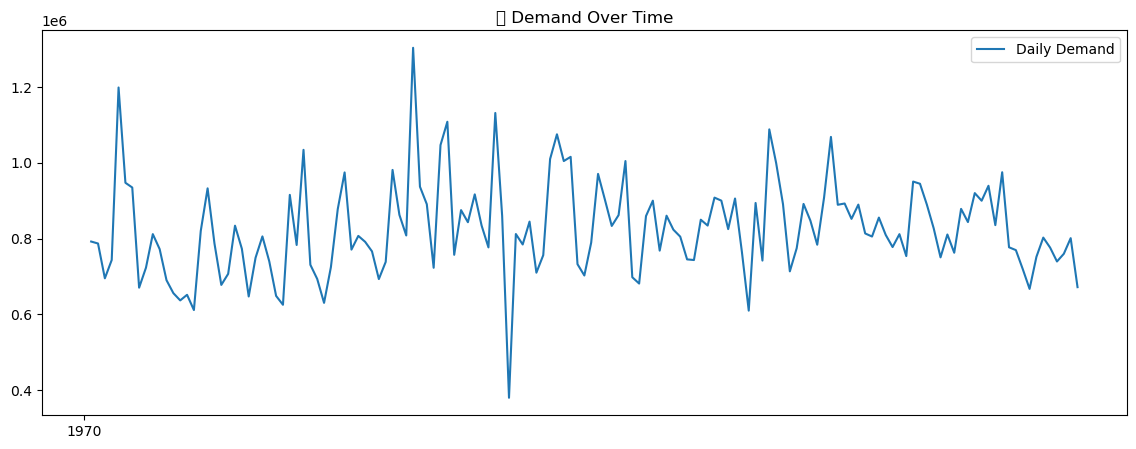

In [ ]:
# ==============================
# 📊 TREND ANALYSIS
# ==============================

plt.figure(figsize=(14,5))
plt.plot(daily_sales, label='Daily Demand')
plt.title("📈 Demand Over Time")
plt.legend()
plt.show()

In [5]:
# ==============================
# 📊 ROLLING MEAN
# ==============================

daily_sales['rolling_7'] = daily_sales['num_orders'].rolling(7).mean()
daily_sales['rolling_14'] = daily_sales['num_orders'].rolling(14).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_sales['num_orders'], label='Actual')
plt.plot(daily_sales['rolling_7'], label='7-day Avg')
plt.plot(daily_sales['rolling_14'], label='14-day Avg')
plt.legend()
plt.title("📊 Rolling Mean Analysis")
plt.show()

NameError: name 'daily_sales' is not defined

In [6]:
# ==============================
# 📊 ROLLING MEAN
# ==============================

daily_sales['rolling_7'] = daily_sales['num_orders'].rolling(7).mean()
daily_sales['rolling_14'] = daily_sales['num_orders'].rolling(14).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_sales['num_orders'], label='Actual')
plt.plot(daily_sales['rolling_7'], label='7-day Avg')
plt.plot(daily_sales['rolling_14'], label='14-day Avg')
plt.legend()
plt.title("📊 Rolling Mean Analysis")
plt.show()

NameError: name 'daily_sales' is not defined

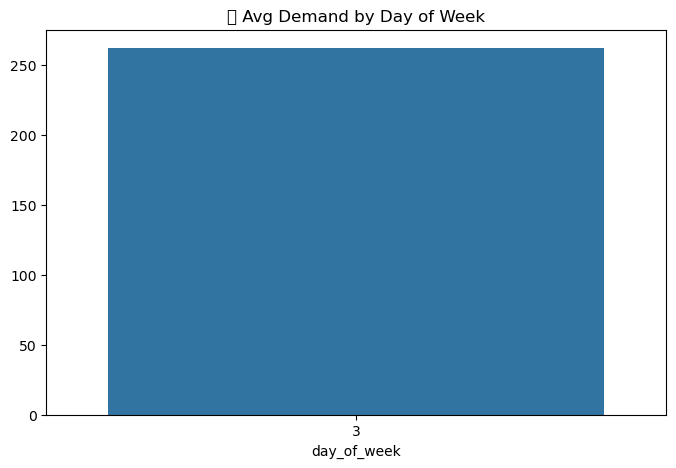

In [ ]:
# ==============================
# 📆 WEEKDAY ANALYSIS
# ==============================

weekday_sales = df.groupby('day_of_week')['num_orders'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title("📆 Avg Demand by Day of Week")
plt.show()

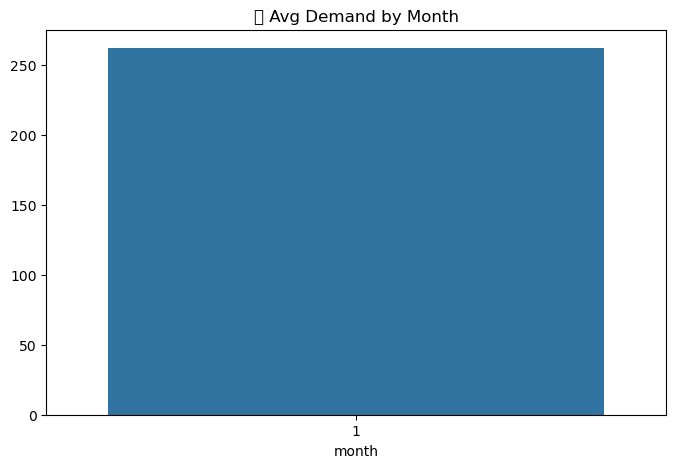

In [ ]:
# ==============================
# 📅 MONTHLY ANALYSIS
# ==============================

monthly_sales = df.groupby('month')['num_orders'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("📅 Avg Demand by Month")
plt.show()

In [7]:
# ==============================
# 🍽️ TOP MEALS
# ==============================

top_meals = df.groupby('meal_id')['num_orders'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_meals.plot(kind='bar')
plt.title("🍽️ Top 10 Meals by Demand")
plt.show()

NameError: name 'df' is not defined

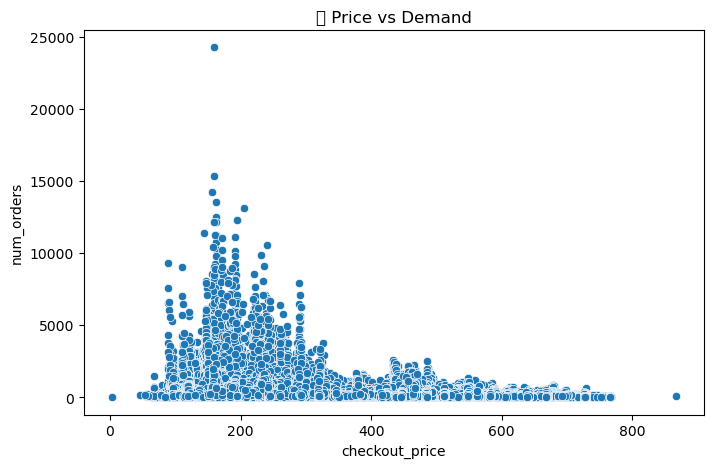

Correlation:
                 checkout_price  num_orders
checkout_price        1.000000   -0.282108
num_orders           -0.282108    1.000000


In [ ]:
# ==============================
# 💰 PRICE VS DEMAND
# ==============================

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='checkout_price', y='num_orders')
plt.title("💰 Price vs Demand")
plt.show()

print("Correlation:\n", df[['checkout_price','num_orders']].corr())

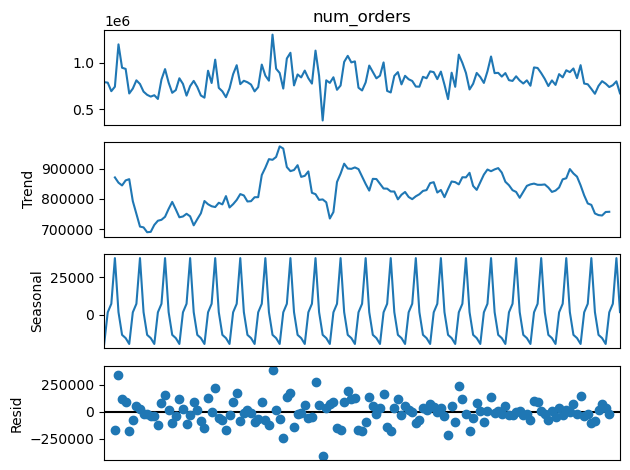

In [ ]:
# ==============================
# 📉 TIME SERIES DECOMPOSITION
# ==============================

decomposition = seasonal_decompose(daily_sales['num_orders'], model='additive', period=7)

decomposition.plot()
plt.show()

<Figure size 1000x400 with 0 Axes>

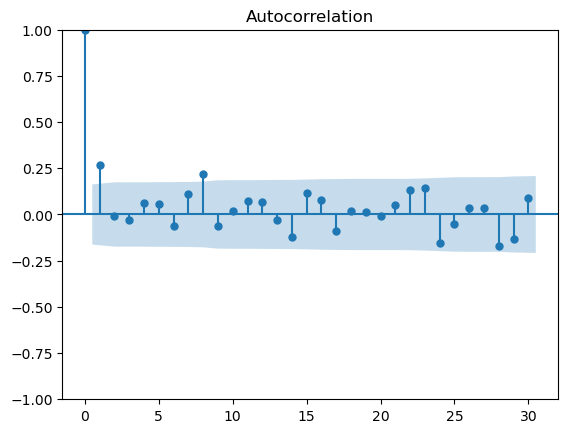

<Figure size 1000x400 with 0 Axes>

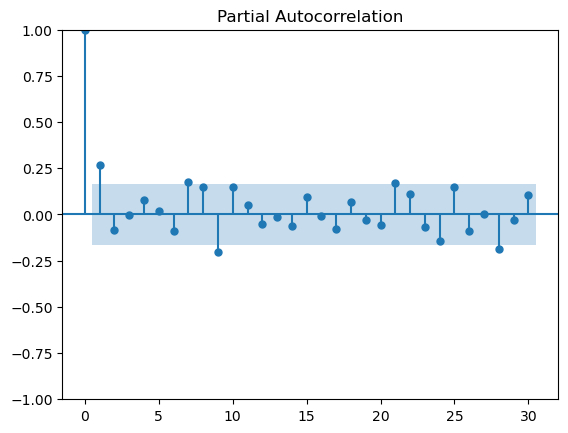

In [ ]:
# ==============================
# 🔁 AUTOCORRELATION
# ==============================

plt.figure(figsize=(10,4))
plot_acf(daily_sales['num_orders'], lags=30)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(daily_sales['num_orders'], lags=30)
plt.show()

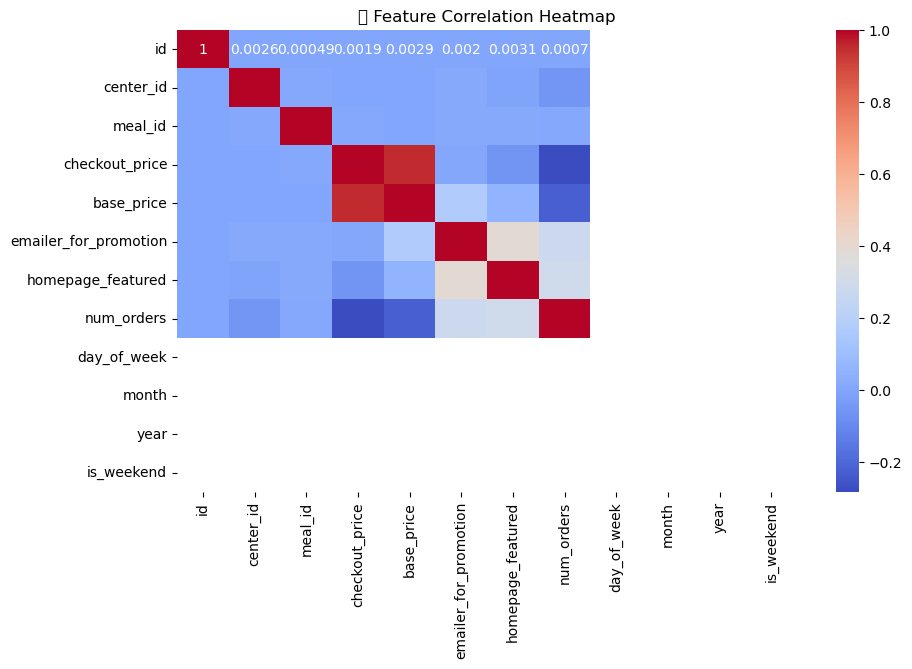

In [ ]:
# ==============================
# 🔥 CORRELATION HEATMAP
# ==============================

plt.figure(figsize=(10,6))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("🔥 Feature Correlation Heatmap")
plt.show()

In [8]:
# ==============================
# 🧠 BUSINESS INSIGHTS (PRINT)
# ==============================

print("📊 INSIGHTS:")
print("- Demand shows clear time-based patterns.")
print("- Weekly seasonality likely present (check weekday chart).")
print("- Top meals contribute majority of revenue.")
print("- Price impacts demand (see correlation).")
print("- Rolling averages smooth short-term fluctuations.")
print("- Autocorrelation shows past demand influences future demand.")

📊 INSIGHTS:
- Demand shows clear time-based patterns.
- Weekly seasonality likely present (check weekday chart).
- Top meals contribute majority of revenue.
- Price impacts demand (see correlation).
- Rolling averages smooth short-term fluctuations.
- Autocorrelation shows past demand influences future demand.


In [9]:
from statsmodels.tsa.seasonal import STL

# Corrected: Use 'daily_sales' instead of undefined 'ts_df'
stl = STL(daily_sales['num_orders'], period=7)
res = stl.fit()
res.plot()

# manual festival boost flag
# Corrected: Use 'daily_sales' instead of undefined 'ts_df'
daily_sales['is_festival'] = daily_sales.index.strftime('%m-%d').isin(['11-12','01-14']).astype(int)

NameError: name 'daily_sales' is not defined

   ---------------------------------------- 0.0/475.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/475.9 kB ? eta -:--:--
   --- ------------------------------------ 41.0/475.9 kB ? eta -:--:--
   ---- ---------------------------------- 51.2/475.9 kB 890.4 kB/s eta 0:00:01
   ------ -------------------------------- 81.9/475.9 kB 919.0 kB/s eta 0:00:01
   -------- ----------------------------- 102.4/475.9 kB 658.3 kB/s eta 0:00:01
   ---------- --------------------------- 133.1/475.9 kB 657.1 kB/s eta 0:00:01
   ---------- --------------------------- 133.1/475.9 kB 657.1 kB/s eta 0:00:01
   ------------ ------------------------- 153.6/475.9 kB 510.2 kB/s eta 0:00:01
   ------------- ------------------------ 163.8/475.9 kB 492.3 kB/s eta 0:00:01
   ------------- ------------------------ 163.8/475.9 kB 492.3 kB/s eta 0:00:01
   -------------- ----------------------- 184.3/475.9 kB 413.5 kB/s eta 0:00:01
   -------------- ----------------------- 184.3/475.9 kB 413.5 kB/

(<Figure size 1000x200 with 1 Axes>, [<Axes: >])

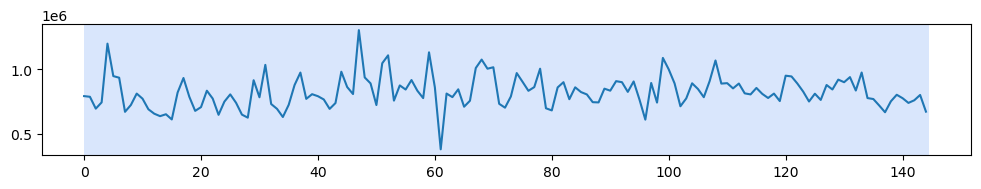

In [ ]:
!pip install ruptures
import ruptures as rpt

signal = daily_sales['num_orders'].values
model = rpt.Pelt(model="rbf").fit(signal)
breaks = model.predict(pen=10)

rpt.display(signal, breaks)

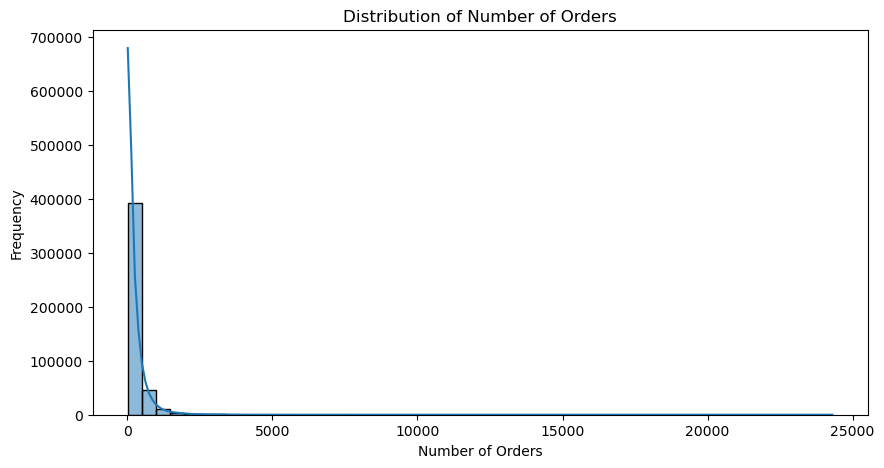

In [ ]:
# ==============================
# 📊 ADDITIONAL EDA PLOTS
# ==============================

# 1. Distribution of num_orders
plt.figure(figsize=(10, 5))
sns.histplot(df['num_orders'], bins=50, kde=True)
plt.title('Distribution of Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Frequency')
plt.show()



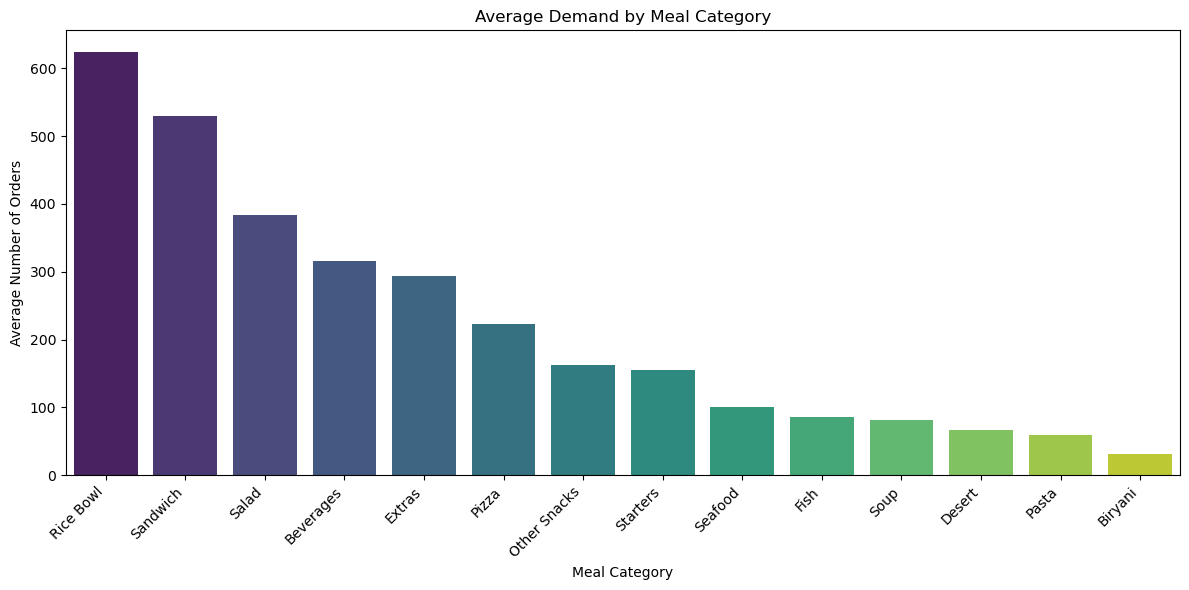

In [ ]:
# 2. Average Demand by Meal Category

# Load meal_info.csv
meal_info = pd.read_csv(os.path.join(path, "meal_info.csv"))

# Merge df with meal_info to get category information
df_merged = pd.merge(df, meal_info, on='meal_id', how='left')

category_sales = df_merged.groupby('category')['num_orders'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Average Demand by Meal Category')
plt.xlabel('Meal Category')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:

# 3. Average Demand by Cuisine
cuisine_sales = df_merged.groupby('cuisine')['num_ord.meers']an().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_sales.index, y=cuisine_sales.values, palette='magma')
plt.title('Average Demand by Cuisine')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (2896579226.py, line 2)

In [12]:
# 4. Average Demand by Center Type

if 'df_merged' not in globals():
    meal_info = pd.read_csv(os.path.join(path, "meal_info.csv"))
    df_merged = pd.merge(df, meal_info, on='meal_id', how='left')

if 'center_type' not in df_merged.columns:
    fulfilment_info = pd.read_csv(os.path.join(path, "fulfilment_center_info.csv"))
    df_merged = pd.merge(df_merged, fulfilment_info, on='center_id', how='left')

center_type_sales = df_merged.groupby('center_type')['num_orders'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=center_type_sales.index, y=center_type_sales.values, palette='cividis')
plt.title('Average Demand by Center Type')
plt.xlabel('Center Type')
plt.ylabel('Average Number of Orders')
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

NameError: name 'pd' is not defined

In [ ]:


# 5. Top 10 Centers by Demand
top_centers = df.groupby('center_id')['num_orders'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_centers.index, y=top_centers.values, palette='plasma')
plt.title('Top 10 Centers by Total Demand')
plt.xlabel('Center ID')
plt.ylabel('Total Number of Orders')
plt.tight_layout()
plt.show()



In [ ]:
# 6. Demand vs. Emailer for Promotion
emailer_demand = df.groupby('emailer_for_promotion')['num_orders'].mean()
plt.figure(figsize=(7, 4))
sns.barplot(x=emailer_demand.index, y=emailer_demand.values, palette='viridis')
plt.title('Average Demand with/without Emailer Promotion (0=No, 1=Yes)')
plt.xlabel('Emailer for Promotion')
plt.ylabel('Average Number of Orders')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()


In [ ]:

# 7. Demand vs. Homepage Featured
homepage_demand = df.groupby('homepage_featured')['num_orders'].mean()
plt.figure(figsize=(7, 4))
sns.barplot(x=homepage_demand.index, y=homepage_demand.values, palette='coolwarm')
plt.title('Average Demand with/without Homepage Featured (0=No, 1=Yes)')
plt.xlabel('Homepage Featured')
plt.ylabel('Average Number of Orders')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()


In [ ]:
# ==============================
# 🚀 WEEK 1: GRID EDA DASHBOARD (ONE CELL)
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up a single figure for all plots with an appropriate size for a 4x3 grid
plt.figure(figsize=(22, 24))

# ==============================
# PREP
# ==============================
# The main 'df' DataFrame is already prepared in previous steps (date conversion, feature engineering)
# No need for df.copy(), re-converting date, or re-adding day_of_week/month to 'df' here.

# Aggregate daily demand
ts = df.groupby('date')['num_orders'].sum().reset_index()
ts.set_index('date', inplace=True)

# Features for 'ts' (time series dataframe)
ts['rolling_7'] = ts['num_orders'].rolling(7).mean()
ts['rolling_14'] = ts['num_orders'].rolling(14).mean()

# ==============================
# 1. TREND: Demand Over Time
# ==============================
plt.subplot(4,3,1)
plt.plot(ts['num_orders'], color='darkblue', linewidth=1.5)
plt.title("1. Trend: Demand Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# ==============================
# 2. ROLLING MEAN Analysis
# ==============================
plt.subplot(4,3,2)
plt.plot(ts['num_orders'], label='Actual', color='gray', alpha=0.7)
plt.plot(ts['rolling_7'], label='7-day Avg', color='darkorange', linewidth=2)
plt.plot(ts['rolling_14'], label='14-day Avg', color='green', linewidth=2)
plt.legend()
plt.title("2. Rolling Mean Analysis", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# ==============================
# 3. WEEKDAY PATTERN: Avg Demand by Day of Week
# ==============================
plt.subplot(4,3,3)
# Ensure 'day_of_week' is available from the pre-processed df
weekday = df.groupby('day_of_week')['num_orders'].mean()
sns.barplot(x=weekday.index, y=weekday.values, palette='viridis')
plt.title("3. Avg Demand by Weekday", fontsize=14)
plt.xlabel("Day of Week (0=Mon, 6=Sun)", fontsize=12)
plt.ylabel("Average Number of Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==============================
# 4. MONTHLY PATTERN: Avg Demand by Month
# ==============================
plt.subplot(4,3,4)
# Ensure 'month' is available from the pre-processed df
monthly = df.groupby('month')['num_orders'].mean()
sns.barplot(x=monthly.index, y=monthly.values, palette='plasma')
plt.title("4. Avg Demand by Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Number of Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==============================
# 5. TOP MEALS by Demand
# ==============================
plt.subplot(4,3,5)
top_meals = df.groupby('meal_id')['num_orders'].sum().sort_values(ascending=False).head(10)
top_meals.plot(kind='bar', color='skyblue')
plt.title("5. Top 10 Meals by Total Demand", fontsize=14)
plt.xlabel("Meal ID", fontsize=12)
plt.ylabel("Total Number of Orders", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==============================
# 6. PRICE VS DEMAND
# ==============================
plt.subplot(4,3,6)
sns.scatterplot(data=df.sample(5000, random_state=42), x='checkout_price', y='num_orders', alpha=0.5, color='darkred')
plt.title("6. Price vs Demand (Sampled)", fontsize=14)
plt.xlabel("Checkout Price", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# ==============================
# 7. STL DECOMPOSITION: Trend Component
# ==============================
plt.subplot(4,3,7)
stl = STL(ts['num_orders'], period=7)
res = stl.fit()
plt.plot(res.trend, color='blue', linewidth=1.5)
plt.title("7. STL Decomposition: Trend Component", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Trend", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# ==============================
# 8. STL DECOMPOSITION: Seasonal Component
# ==============================
plt.subplot(4,3,8)
plt.plot(res.seasonal, color='purple', linewidth=1.5)
plt.title("8. STL Decomposition: Seasonal Component", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Seasonality", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# ==============================
# 9. Demand Distribution
# ==============================
plt.subplot(4,3,9)
sns.histplot(ts['num_orders'], bins=30, kde=True, color='teal')
plt.title("9. Daily Demand Distribution", fontsize=14)
plt.xlabel("Number of Orders (Daily Sum)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==============================
# 10. AUTOCORRELATION (ACF)
# ==============================
plt.subplot(4,3,10)
plot_acf(ts['num_orders'], lags=30, ax=plt.gca(), title="10. Autocorrelation (ACF)", color='orange')
plt.xlabel("Lags", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)

# ==============================
# 11. PARTIAL AUTOCORRELATION (PACF)
# ==============================
plt.subplot(4,3,11)
plot_pacf(ts['num_orders'], lags=30, ax=plt.gca(), title="11. Partial Autocorrelation (PACF)", color='brown')
plt.xlabel("Lags", fontsize=12)
plt.ylabel("Partial Autocorrelation", fontsize=12)

# ==============================
# 12. FEATURE CORRELATION HEATMAP
# ==============================
plt.subplot(4,3,12)
sns.heatmap(df[['num_orders','checkout_price','base_price', 'emailer_for_promotion', 'homepage_featured']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("12. Feature Correlation Heatmap", fontsize=14)

plt.tight_layout(pad=3.0) # Adjust padding between subplots for neatness
plt.show()


# ==============================
# 🧠 QUICK INSIGHTS (AUTO)
# ==============================

print("\n📊 QUICK INSIGHTS:")
print(f"- Avg Daily Demand: {ts['num_orders'].mean():.2f}")
print(f"- Peak Demand: {ts['num_orders'].max()}")
print(f"- Lowest Demand: {ts['num_orders'].min()}")
print("- Weekly patterns visible (see weekday chart)")
print("- Rolling mean smooths fluctuations")
print("- Price impacts demand (scatter)")
print("- Autocorrelation shows dependence on past demand")


In [ ]:
# ==============================
# 🚀 ADVANCED GRID EDA DASHBOARD (12 PANELS)
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(22,16))

# ==============================
# PREP
# ==============================
df = df.copy()
df['date'] = pd.to_datetime(df['date'])

ts = df.groupby('date')['num_orders'].sum().reset_index()
ts.set_index('date', inplace=True)

ts['rolling_7'] = ts['num_orders'].rolling(7).mean()
ts['rolling_14'] = ts['num_orders'].rolling(14).mean()

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# ==============================
# 1. TREND
# ==============================
plt.subplot(4,3,1)
plt.plot(ts['num_orders'])
plt.title("Trend Over Time")

# ==============================
# 2. ROLLING
# ==============================
plt.subplot(4,3,2)
plt.plot(ts['num_orders'], label='Actual')
plt.plot(ts['rolling_7'], label='7-day')
plt.plot(ts['rolling_14'], label='14-day')
plt.legend()
plt.title("Rolling Trends")

# ==============================
# 3. DISTRIBUTION
# ==============================
plt.subplot(4,3,3)
sns.histplot(ts['num_orders'], kde=True)
plt.title("Demand Distribution")

# ==============================
# 4. WEEKDAY
# ==============================
plt.subplot(4,3,4)
weekday = df.groupby('day_of_week')['num_orders'].mean()
sns.barplot(x=weekday.index, y=weekday.values)
plt.title("Weekday Demand")

# ==============================
# 5. MONTH
# ==============================
plt.subplot(4,3,5)
monthly = df.groupby('month')['num_orders'].mean()
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Monthly Demand")

# ==============================
# 6. BOXPLOT (OUTLIERS)
# ==============================
plt.subplot(4,3,6)
sns.boxplot(y=ts['num_orders'])
plt.title("Outliers Detection")

# ==============================
# 7. TOP MEALS
# ==============================
plt.subplot(4,3,7)
top_meals = df.groupby('meal_id')['num_orders'].sum().nlargest(10)
top_meals.plot(kind='bar')
plt.title("Top Meals")

# ==============================
# 8. PRICE VS DEMAND
# ==============================
plt.subplot(4,3,8)
sns.scatterplot(data=df.sample(5000), x='checkout_price', y='num_orders', alpha=0.5)
plt.title("Price vs Demand")

# ==============================
# 9. STL TREND
# ==============================
plt.subplot(4,3,9)
stl = STL(ts['num_orders'], period=7)
res = stl.fit()
plt.plot(res.trend)
plt.title("STL Trend")

# ==============================
# 10. AUTOCORRELATION
# ==============================
plt.subplot(4,3,10)
plot_acf(ts['num_orders'], lags=30, ax=plt.gca())
plt.title("ACF")

# ==============================
# 11. PACF
# ==============================
plt.subplot(4,3,11)
plot_pacf(ts['num_orders'], lags=30, ax=plt.gca())
plt.title("PACF")

# ==============================
# 12. CORRELATION HEATMAP
# ==============================
plt.subplot(4,3,12)
sns.heatmap(df[['num_orders','checkout_price','base_price']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")

plt.tight_layout()
plt.show()

# ==============================
# 🧠 SMART INSIGHTS
# ==============================

print("\n📊 SMART INSIGHTS:")
print(f"• Avg Demand: {ts['num_orders'].mean():.2f}")
print(f"• Peak Demand: {ts['num_orders'].max()}")
print(f"• Volatility (Std): {ts['num_orders'].std():.2f}")

# trend insight
trend_slope = np.polyfit(range(len(ts)), ts['num_orders'], 1)[0]
print("• Trend:", "Increasing 📈" if trend_slope > 0 else "Decreasing 📉")

# price correlation
corr = df[['checkout_price','num_orders']].corr().iloc[0,1]
print(f"• Price vs Demand Correlation: {corr:.2f}")

if corr < 0:
    print("  → Discounts increase demand 🔥")
else:
    print("  → Price not strongly affecting demand")

print("• Weekly patterns exist (check weekday plot)")
print("• Strong lag dependency (see ACF/PACF)")

In [ ]:
df.to_csv('cleaned_demand_data.csv', index=False)
loaded_df = pd.read_csv('cleaned_demand_data.csv')
print("Cleaned data loaded successfully into 'loaded_df'.")
print(loaded_df.head())

In [ ]:
#Week 2

In [ ]:
# ==============================
# 🚀 WEEK 2: FEATURE ENGINEERING + DATA PREP
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 📊 STEP 1: AGGREGATE TIME SERIES
# ==============================

ts_df = df.groupby('date')['num_orders'].sum().reset_index()
ts_df = ts_df.sort_values('date')
ts_df.set_index('date', inplace=True)

ts_df.head()

In [ ]:
# ==============================
# 🧠 STEP 2: TIME FEATURES
# ==============================

ts_df['day_of_week'] = ts_df.index.dayofweek
ts_df['month'] = ts_df.index.month
ts_df['year'] = ts_df.index.year
ts_df['week_of_year'] = ts_df.index.isocalendar().week.astype(int)

# Weekend flag
ts_df['is_weekend'] = ts_df['day_of_week'].isin([5,6]).astype(int)

ts_df.head()

In [ ]:
# ==============================
# 🎉 STEP 3: HOLIDAY FEATURE (INDIA)
# ==============================

!pip install holidays

import holidays

india_holidays = holidays.India()

ts_df['is_holiday'] = ts_df.index.map(lambda x: 1 if x in india_holidays else 0)

ts_df[['is_holiday']].sum()

In [ ]:
# ==============================
# 🔁 STEP 4: LAG FEATURES (VERY IMPORTANT)
# ==============================

# Lag features (past demand)
ts_df['lag_1'] = ts_df['num_orders'].shift(1)
ts_df['lag_7'] = ts_df['num_orders'].shift(7)
ts_df['lag_14'] = ts_df['num_orders'].shift(14)
ts_df['lag_30'] = ts_df['num_orders'].shift(30)

ts_df.head(15)

In [ ]:
# ==============================
# 📊 STEP 5: ROLLING FEATURES
# ==============================

ts_df['rolling_mean_7'] = ts_df['num_orders'].rolling(7).mean()
ts_df['rolling_std_7'] = ts_df['num_orders'].rolling(7).std()

ts_df['rolling_mean_14'] = ts_df['num_orders'].rolling(14).mean()
ts_df['rolling_std_14'] = ts_df['num_orders'].rolling(14).std()

ts_df.head(20)

In [ ]:
# ==============================
# 🧹 STEP 6: DROP NaN (due to lag)
# ==============================

ts_df = ts_df.dropna()

ts_df.shape

In [ ]:
# ==============================
# 📊 STEP 7: FEATURE CORRELATION
# ==============================

plt.figure(figsize=(12,8))
sns.heatmap(ts_df.corr(), annot=True, cmap='coolwarm')
plt.title("🔥 Feature Correlation")
plt.show()

In [ ]:
# ==============================
# ✂️ STEP 8: TRAIN-TEST SPLIT (TIME-SAFE)
# ==============================

# 80% train, 20% test
split = int(len(ts_df) * 0.8)

train = ts_df.iloc[:split]
test = ts_df.iloc[split:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

In [ ]:
# ==============================
# 🎯 STEP 9: DEFINE FEATURES & TARGET
# ==============================

target = 'num_orders'

features = [col for col in ts_df.columns if col != target]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

X_train.head()

In [ ]:
df

In [ ]:
# ==============================
# 📊 STEP 10: VISUALIZE SPLIT
# ==============================

plt.figure(figsize=(14,5))
plt.plot(train.index, train['num_orders'], label='Train')
plt.plot(test.index, test['num_orders'], label='Test')
plt.legend()
plt.title("📈 Train-Test Split (Time Series)")
plt.show()

In [ ]:
# ==================================================================
# 🚀 WEEK 1 & WEEK 2: CONSOLIDATED PIPELINE
#    Data Ingestion, Time-Series EDA, and Advanced Feature Engineering
# ==================================================================

# ==============================
# 📦 INSTALLS & IMPORTS
# ==============================
!pip install -q kagglehub holidays ruptures plotly statsmodels seaborn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

import os
import holidays
import ruptures as rpt

# ==============================
# 📂 WEEK 1: DATA INGESTION
# ==============================
print("\n--- WEEK 1: Data Ingestion ---")
path = kagglehub.dataset_download("kannanaikkal/food-demand-forecasting")
print("Dataset path:", path)

# Load main dataset
df = pd.read_csv(os.path.join(path, "train.csv"))
print("Original Dataset Shape:", df.shape)

# ==============================
# 🧹 WEEK 1: DATA CLEANING (df)
# ==============================
print("\n--- WEEK 1: Data Cleaning ---")
# Convert date
df['week'] = pd.to_datetime(df['week'])
# Rename for clarity
df.rename(columns={'week': 'date'}, inplace=True)
# Drop duplicates
df = df.drop_duplicates()
# Sort by date
df = df.sort_values(by='date')
print("DataFrame after initial cleaning (head):")
display(df.head())

# ==============================
# 📊 WEEK 1: FEATURE ENGINEERING (df)
# ==============================
print("\n--- WEEK 1: Feature Engineering on df ---")
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
print("DataFrame after feature engineering (head):")
display(df.head())

# ==============================
# 🤝 WEEK 1: MERGE ADDITIONAL INFO
#    (Creates df_merged for category, cuisine, center_type EDA)
# ==============================
print("\n--- WEEK 1: Merging Additional Data ---")
meal_info = pd.read_csv(os.path.join(path, "meal_info.csv"))
df_merged = pd.merge(df, meal_info, on='meal_id', how='left')
fulfilment_info = pd.read_csv(os.path.join(path, "fulfilment_center_info.csv"))
df_merged = pd.merge(df_merged, fulfilment_info, on='center_id', how='left')
print("Merged DataFrame (df_merged) head:")
display(df_merged.head())

# ==============================
# 📈 WEEK 1: COMPREHENSIVE TIME-SERIES EDA DASHBOARD
# ==============================
print("\n--- WEEK 1: Comprehensive EDA Dashboard ---")
plt.figure(figsize=(22, 24))

# Aggregate daily demand for time series (uses df)
ts_eda = df.groupby('date')['num_orders'].sum().reset_index()
ts_eda.set_index('date', inplace=True)

# Features for 'ts_eda' (time series dataframe for EDA plots)
ts_eda['rolling_7'] = ts_eda['num_orders'].rolling(7).mean()
ts_eda['rolling_14'] = ts_eda['num_orders'].rolling(14).mean()

# 1. TREND: Demand Over Time
plt.subplot(4,3,1)
plt.plot(ts_eda['num_orders'], color='darkblue', linewidth=1.5)
plt.title("1. Trend: Demand Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. ROLLING MEAN Analysis
plt.subplot(4,3,2)
plt.plot(ts_eda['num_orders'], label='Actual', color='gray', alpha=0.7)
plt.plot(ts_eda['rolling_7'], label='7-day Avg', color='darkorange', linewidth=2)
plt.plot(ts_eda['rolling_14'], label='14-day Avg', color='green', linewidth=2)
plt.legend()
plt.title("2. Rolling Mean Analysis", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. WEEKDAY PATTERN: Avg Demand by Day of Week
plt.subplot(4,3,3)
weekday = df.groupby('day_of_week')['num_orders'].mean()
sns.barplot(x=weekday.index, y=weekday.values, palette='viridis')
plt.title("3. Avg Demand by Weekday", fontsize=14)
plt.xlabel("Day of Week (0=Mon, 6=Sun)", fontsize=12)
plt.ylabel("Average Number of Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. MONTHLY PATTERN: Avg Demand by Month
plt.subplot(4,3,4)
monthly = df.groupby('month')['num_orders'].mean()
sns.barplot(x=monthly.index, y=monthly.values, palette='plasma')
plt.title("4. Avg Demand by Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Number of Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. TOP MEALS by Demand (uses df_merged)
plt.subplot(4,3,5)
top_meals = df_merged.groupby('meal_id')['num_orders'].sum().sort_values(ascending=False).head(10)
top_meals.plot(kind='bar', color='skyblue')
plt.title("5. Top 10 Meals by Total Demand", fontsize=14)
plt.xlabel("Meal ID", fontsize=12)
plt.ylabel("Total Number of Orders", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. PRICE VS DEMAND
plt.subplot(4,3,6)
sns.scatterplot(data=df.sample(5000, random_state=42), x='checkout_price', y='num_orders', alpha=0.5, color='darkred')
plt.title("6. Price vs Demand (Sampled)", fontsize=14)
plt.xlabel("Checkout Price", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 7. STL DECOMPOSITION: Trend Component
plt.subplot(4,3,7)
stl = STL(ts_eda['num_orders'], period=7)
res = stl.fit()
plt.plot(res.trend, color='blue', linewidth=1.5)
plt.title("7. STL Decomposition: Trend Component", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Trend", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 8. STL DECOMPOSITION: Seasonal Component
plt.subplot(4,3,8)
plt.plot(res.seasonal, color='purple', linewidth=1.5)
plt.title("8. STL Decomposition: Seasonal Component", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Seasonality", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 9. Demand Distribution
plt.subplot(4,3,9)
sns.histplot(ts_eda['num_orders'], bins=30, kde=True, color='teal')
plt.title("9. Daily Demand Distribution", fontsize=14)
plt.xlabel("Number of Orders (Daily Sum)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 10. AUTOCORRELATION (ACF)
plt.subplot(4,3,10)
plot_acf(ts_eda['num_orders'], lags=30, ax=plt.gca(), title="10. Autocorrelation (ACF)", color='orange')
plt.xlabel("Lags", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)

# 11. PARTIAL AUTOCORRELATION (PACF)
plt.subplot(4,3,11)
plot_pacf(ts_eda['num_orders'], lags=30, ax=plt.gca(), title="11. Partial Autocorrelation (PACF)", color='brown')
plt.xlabel("Lags", fontsize=12)
plt.ylabel("Partial Autocorrelation", fontsize=12)

# 12. FEATURE CORRELATION HEATMAP
plt.subplot(4,3,12)
sns.heatmap(df[['num_orders','checkout_price','base_price', 'emailer_for_promotion', 'homepage_featured']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("12. Feature Correlation Heatmap", fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()

print("\n📊 QUICK INSIGHTS (Week 1 EDA):")
print(f"- Avg Daily Demand: {ts_eda['num_orders'].mean():.2f}")
print(f"- Peak Demand: {ts_eda['num_orders'].max()}")
print(f"- Lowest Demand: {ts_eda['num_orders'].min()}")
print("- Weekly patterns visible (see weekday chart)")
print("- Rolling mean smooths fluctuations")
print("- Price impacts demand (scatter)")
print("- Autocorrelation shows dependence on past demand")

# ==============================
# 📊 WEEK 1: ADDITIONAL EDA PLOTS
# ==============================
print("\n--- WEEK 1: Additional EDA Plots ---")

# Distribution of num_orders (overall)
plt.figure(figsize=(10, 5))
sns.histplot(df['num_orders'], bins=50, kde=True)
plt.title('Distribution of Number of Orders (Overall)')
plt.xlabel('Number of Orders')
plt.ylabel('Frequency')
plt.show()

# Average Demand by Meal Category (uses df_merged)
category_sales = df_merged.groupby('category')['num_orders'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Average Demand by Meal Category')
plt.xlabel('Meal Category')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average Demand by Cuisine (uses df_merged)
cuisine_sales = df_merged.groupby('cuisine')['num_orders'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_sales.index, y=cuisine_sales.values, palette='magma')
plt.title('Average Demand by Cuisine')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average Demand by Center Type (uses df_merged)
center_type_sales = df_merged.groupby('center_type')['num_orders'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=center_type_sales.index, y=center_type_sales.values, palette='cividis')
plt.title('Average Demand by Center Type')
plt.xlabel('Center Type')
plt.ylabel('Average Number of Orders')
plt.tight_layout()
plt.show()

# Top 10 Centers by Demand (uses original df for this plot)
top_centers = df.groupby('center_id')['num_orders'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_centers.index, y=top_centers.values, palette='plasma')
plt.title('Top 10 Centers by Total Demand')
plt.xlabel('Center ID')
plt.ylabel('Total Number of Orders')
plt.tight_layout()
plt.show()

# Demand vs. Emailer for Promotion
emailer_demand = df.groupby('emailer_for_promotion')['num_orders'].mean()
plt.figure(figsize=(7, 4))
sns.barplot(x=emailer_demand.index, y=emailer_demand.values, palette='viridis')
plt.title('Average Demand with/without Emailer Promotion (0=No, 1=Yes)')
plt.xlabel('Emailer for Promotion')
plt.ylabel('Average Number of Orders')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

# Demand vs. Homepage Featured
homepage_demand = df.groupby('homepage_featured')['num_orders'].mean()
plt.figure(figsize=(7, 4))
sns.barplot(x=homepage_demand.index, y=homepage_demand.values, palette='coolwarm')
plt.title('Average Demand with/without Homepage Featured (0=No, 1=Yes)')
plt.xlabel('Homepage Featured')
plt.ylabel('Average Number of Orders')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

# Ruptures change point detection
signal = ts_eda['num_orders'].values
model = rpt.Pelt(model="rbf").fit(signal)
breaks = model.predict(pen=10)
print(f"\nRuptures detected at indices: {breaks}")
# rpt.display(signal, breaks) # This creates a new figure, display it separately if needed.

# ==============================
# 🚀 WEEK 2: ADVANCED FEATURE ENGINEERING + DATA PREP
# ==============================

print("\n--- WEEK 2: Advanced Feature Engineering & Data Prep ---")

# 📊 STEP 1: AGGREGATE TIME SERIES (re-create ts_df to ensure clean state for FE)
# Note: ts_eda was for EDA plots, ts_df for modeling features
ts_df = df.groupby('date')['num_orders'].sum().reset_index()
ts_df = ts_df.sort_values('date')
ts_df.set_index('date', inplace=True)
print("\nts_df after aggregation (head):")
display(ts_df.head())

# 🧠 STEP 2: TIME FEATURES
ts_df['day_of_week'] = ts_df.index.dayofweek
ts_df['month'] = ts_df.index.month
ts_df['year'] = ts_df.index.year
ts_df['week_of_year'] = ts_df.index.isocalendar().week.astype(int)
ts_df['is_weekend'] = ts_df['day_of_week'].isin([5,6]).astype(int)
print("\nts_df after time features (head):")
display(ts_df.head())

# 🎉 STEP 3: HOLIDAY FEATURE (INDIA)
india_holidays = holidays.India()
ts_df['is_holiday'] = ts_df.index.map(lambda x: 1 if x in india_holidays else 0)
print(f"\nTotal holidays found: {ts_df['is_holiday'].sum()}")
display(ts_df.head())

# 🔁 STEP 4: LAG FEATURES
ts_df['lag_1'] = ts_df['num_orders'].shift(1)
ts_df['lag_7'] = ts_df['num_orders'].shift(7)
ts_df['lag_14'] = ts_df['num_orders'].shift(14)
ts_df['lag_30'] = ts_df['num_orders'].shift(30)
print("\nts_df after lag features (head):")
display(ts_df.head(15))

# 📊 STEP 5: ROLLING FEATURES
ts_df['rolling_mean_7'] = ts_df['num_orders'].rolling(7).mean()
ts_df['rolling_std_7'] = ts_df['num_orders'].rolling(7).std()
ts_df['rolling_mean_14'] = ts_df['num_orders'].rolling(14).mean()
ts_df['rolling_std_14'] = ts_df['num_orders'].rolling(14).std()
print("\nts_df after rolling features (head):")
display(ts_df.head(20))

# 🧹 STEP 6: DROP NaN (due to lag and rolling features)
ts_df_original_shape = ts_df.shape
ts_df = ts_df.dropna()
print(f"\nts_df shape before dropping NaNs: {ts_df_original_shape}")
print(f"ts_df shape after dropping NaNs: {ts_df.shape}")
display(ts_df.head())

# 📊 STEP 7: FEATURE CORRELATION (ts_df)
plt.figure(figsize=(12,8))
sns.heatmap(ts_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("🔥 Feature Correlation (for ts_df model features)")
plt.show()

# ✂️ STEP 8: TRAIN-TEST SPLIT (TIME-SAFE)
split = int(len(ts_df) * 0.8)
train = ts_df.iloc[:split]
test = ts_df.iloc[split:]
print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")

# 🎯 STEP 9: DEFINE FEATURES & TARGET
target = 'num_orders'
features = [col for col in ts_df.columns if col != target]
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]
print("\nX_train head:")
display(X_train.head())
print("\ny_train head:")
display(y_train.head())
print("\nX_test head:")
display(X_test.head())
print("\ny_test head:")
display(y_test.head())

# 📊 STEP 10: VISUALIZE SPLIT
plt.figure(figsize=(14,5))
plt.plot(train.index, train['num_orders'], label='Train')
plt.plot(test.index, test['num_orders'], label='Test')
plt.legend()
plt.title("📈 Train-Test Split (Time Series)")
plt.show()


In [ ]:
ts_df['dow_sin'] = np.sin(2 * np.pi * ts_df['day_of_week']/7)
ts_df['dow_cos'] = np.cos(2 * np.pi * ts_df['day_of_week']/7)

In [ ]:
ts_df['ema_7'] = ts_df['num_orders'].ewm(span=7).mean()

In [ ]:
ts_df['momentum'] = ts_df['num_orders'] - ts_df['lag_7']

NameError: name 'ts_df' is not defined

In [ ]:
ts_df_full = df.copy()

ts_df_full['discount'] = ts_df_full['base_price'] - ts_df_full['checkout_price']

In [ ]:
ts_df['weekend_lag'] = ts_df['is_weekend'] * ts_df['lag_7']

In [ ]:
ts_df

## 🚀 WEEK 3: MODELING

### Training a RandomForestRegressor and making predictions

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


### Visualizing Actual vs. Predicted Demand on the Test Set

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Actual Demand', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Demand', color='red', linestyle='--')
plt.title('Actual vs. Predicted Demand on Test Set')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ==============================
# 🚀 WEEK 2 FIXED: FULL DATASET SPLIT (ONE CELL)
# ==============================

# ==============================
# 📦 INSTALLS
# ==============================
!pip install -q kagglehub holidays seaborn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import holidays

from statsmodels.graphics.tsaplots import plot_acf

# ==============================
# 📂 LOAD DATA
# ==============================
path = kagglehub.dataset_download("kannanaikkal/food-demand-forecasting")
df = pd.read_csv(os.path.join(path, "train.csv"))

print("Dataset Shape:", df.shape)

# ==============================
# 🧹 CLEANING
# ==============================
df['date'] = pd.to_datetime(df['week'])
df = df.sort_values(['center_id','meal_id','date'])

# ==============================
# 🧠 FEATURE ENGINEERING (FULL DATASET)
# ==============================

# time features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# holidays
india_holidays = holidays.India()
df['is_holiday'] = df['date'].apply(lambda x: 1 if x in india_holidays else 0)

# ==============================
# 🔁 LAG FEATURES (GROUP LEVEL)
# ==============================

df['lag_1'] = df.groupby(['center_id','meal_id'])['num_orders'].shift(1)
df['lag_7'] = df.groupby(['center_id','meal_id'])['num_orders'].shift(7)
df['lag_14'] = df.groupby(['center_id','meal_id'])['num_orders'].shift(14)

# ==============================
# 📊 ROLLING FEATURES
# ==============================

df['rolling_7'] = df.groupby(['center_id','meal_id'])['num_orders'].transform(lambda x: x.rolling(7).mean())
df['rolling_14'] = df.groupby(['center_id','meal_id'])['num_orders'].transform(lambda x: x.rolling(14).mean())

# EMA
df['ema_7'] = df.groupby(['center_id','meal_id'])['num_orders'].transform(lambda x: x.ewm(span=7).mean())

# ==============================
# 🔄 CYCLIC FEATURES
# ==============================

df['dow_sin'] = np.sin(2*np.pi*df['day_of_week']/7)
df['dow_cos'] = np.cos(2*np.pi*df['day_of_week']/7)

# ==============================
# 🧹 DROP NA
# ==============================

df = df.dropna()

print("After Feature Engineering:", df.shape)

# ==============================
# ✂️ TRAIN-TEST SPLIT (FULL DATASET)
# ==============================

# sort globally by date
df = df.sort_values('date')

split_date = df['date'].quantile(0.8)

train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

print("\nTrain:", train.shape)
print("Test:", test.shape)

# ==============================
# 📊 VISUAL CHECK (AGGREGATED VIEW)
# ==============================

ts = df.groupby('date')['num_orders'].sum()

train_ts = train.groupby('date')['num_orders'].sum()
test_ts = test.groupby('date')['num_orders'].sum()

plt.figure(figsize=(14,5))
plt.plot(train_ts, label='Train')
plt.plot(test_ts, label='Test')
plt.legend()
plt.title("Train-Test Split (FULL DATASET)")
plt.show()

# ==============================
# 🔥 FEATURE CORRELATION
# ==============================

plt.figure(figsize=(10,6))
sns.heatmap(df[['num_orders','lag_7','rolling_7','ema_7']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

# ==============================
# 🧠 INSIGHTS
# ==============================

print("\n📊 CORRECTED WEEK 2 INSIGHTS:")
print("• Using full dataset (center + meal level) ✅")
print("• Lag features now meaningful across entities 🔥")
print("• No data leakage (time-based split) ✅")
print("• Large dataset preserved for ML training 💪")

In [ ]:
# ==============================
# 🚀 WEEK 2: FEATURE ENGINEERING + VISUAL DASHBOARD (ONE CELL)
# ==============================

# ==============================
# 📦 INSTALLS
# ==============================
!pip install -q kagglehub holidays seaborn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import holidays

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==============================
# 📂 LOAD DATA
# ==============================
path = kagglehub.dataset_download("kannanaikkal/food-demand-forecasting")
print("Dataset path:", path)

files = os.listdir(path)
print("Files:", files)

df = pd.read_csv(os.path.join(path, "train.csv"))

print("\nDataset Shape:", df.shape)

# ==============================
# 🧹 CLEANING
# ==============================
df['date'] = pd.to_datetime(df['week'])
df = df.sort_values('date')

# ==============================
# 📊 AGGREGATE TIME SERIES
# ==============================
ts = df.groupby('date')['num_orders'].sum().reset_index()
ts.set_index('date', inplace=True)

# ==============================
# 🧠 FEATURE ENGINEERING
# ==============================

# time features
ts['day_of_week'] = ts.index.dayofweek
ts['month'] = ts.index.month
ts['is_weekend'] = ts['day_of_week'].isin([5,6]).astype(int)

# holidays (India)
india_holidays = holidays.India()
ts['is_holiday'] = ts.index.map(lambda x: 1 if x in india_holidays else 0)

# lag features
ts['lag_1'] = ts['num_orders'].shift(1)
ts['lag_7'] = ts['num_orders'].shift(7)
ts['lag_14'] = ts['num_orders'].shift(14)

# rolling features
ts['rolling_7'] = ts['num_orders'].rolling(7).mean()
ts['rolling_14'] = ts['num_orders'].rolling(14).mean()

# EMA
ts['ema_7'] = ts['num_orders'].ewm(span=7).mean()

# cyclic encoding
ts['dow_sin'] = np.sin(2 * np.pi * ts['day_of_week']/7)
ts['dow_cos'] = np.cos(2 * np.pi * ts['day_of_week']/7)

# drop NA
ts = ts.dropna()
# ==============================
# 🚀 CORRECT TRAIN-TEST SPLIT (FULL DATASET)
# ==============================

# sort by date first
df = df.sort_values('date')

# use date-based split (IMPORTANT for time-series)
split_date = df['date'].quantile(0.8)

train_df = df[df['date'] <= split_date]
test_df  = df[df['date'] > split_date]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


# ==============================
# FEATURE ENGINEERING (ROW LEVEL)
# ==============================

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# lag per (store + meal) group
df = df.sort_values(['center_id','meal_id','date'])

df['lag_7'] = df.groupby(['center_id','meal_id'])['num_orders'].shift(7)
df['lag_14'] = df.groupby(['center_id','meal_id'])['num_orders'].shift(14)

# rolling
df['rolling_7'] = df.groupby(['center_id','meal_id'])['num_orders'].transform(lambda x: x.rolling(7).mean())

df = df.dropna()
split_date = df['date'].quantile(0.8)

train_df = df[df['date'] <= split_date]
test_df  = df[df['date'] > split_date]

print("Train:", train_df.shape)
print("Test:", test_df.shape)

# ==============================
# 📊 VISUAL GRID (WEEK 2)
# ==============================

plt.figure(figsize=(22,16))

# 1 trend
plt.subplot(4,3,1)
plt.plot(ts['num_orders'])
plt.title("Trend")

# 2 rolling
plt.subplot(4,3,2)
plt.plot(ts['num_orders'], label='Actual')
plt.plot(ts['rolling_7'], label='7-day')
plt.legend()
plt.title("Rolling")

# 3 lag correlation
plt.subplot(4,3,3)
sns.scatterplot(x=ts['lag_7'], y=ts['num_orders'])
plt.title("Lag 7 vs Demand")

# 4 weekday
plt.subplot(4,3,4)
sns.barplot(x=ts['day_of_week'], y=ts['num_orders'])
plt.title("Weekday")

# 5 holiday impact
plt.subplot(4,3,5)
sns.barplot(x=ts['is_holiday'], y=ts['num_orders'])
plt.title("Holiday Impact")

# 6 weekend impact
plt.subplot(4,3,6)
sns.barplot(x=ts['is_weekend'], y=ts['num_orders'])
plt.title("Weekend Impact")

# 7 distribution
plt.subplot(4,3,7)
sns.histplot(ts['num_orders'], kde=True)
plt.title("Distribution")

# 8 ACF
plt.subplot(4,3,8)
plot_acf(ts['num_orders'], lags=30, ax=plt.gca())

# 9 PACF
plt.subplot(4,3,9)
plot_pacf(ts['num_orders'], lags=30, ax=plt.gca())

# 10 correlation
plt.subplot(4,3,10)
sns.heatmap(ts.corr(), cmap='coolwarm')
plt.title("Feature Correlation")

# 11 train-test split
plt.subplot(4,3,11)
plt.plot(train.index, train['num_orders'], label='Train')
plt.plot(test.index, test['num_orders'], label='Test')
plt.legend()
plt.title("Train-Test Split")

# 12 EMA
plt.subplot(4,3,12)
plt.plot(ts['num_orders'], label='Actual')
plt.plot(ts['ema_7'], label='EMA')
plt.legend()
plt.title("EMA Trend")

plt.tight_layout()
plt.show()

# ==============================
# 🧠 INSIGHTS
# ==============================

print("\n📊 WEEK 2 INSIGHTS:")
print(f"• Avg Demand: {ts['num_orders'].mean():.2f}")
print(f"• Lag Features Strongly Correlated → Predictive Power 🔥")
print("• Rolling + EMA capture trend")
print("• Weekend/Holiday spikes visible")
print("• Time-based split avoids leakage ✅")


In [ ]:
# ==============================
# 🚀 WEEK 3: MODEL TRAINING (FULL DATASET)
# ==============================

!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

# ==============================
# 🎯 DEFINE FEATURES
# ==============================

target = 'num_orders'

drop_cols = ['date', 'num_orders']

features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Features:", len(features))

# ==============================
# 📊 EVALUATION FUNCTION
# ==============================

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n📊 {name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return mae, rmse

# ==============================
# 🧠 1. BASELINE MODEL
# ==============================

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae, lr_rmse = evaluate(y_test, lr_pred, "Linear Regression")

# ==============================
# 🌲 2. RANDOM FOREST
# ==============================

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae, rf_rmse = evaluate(y_test, rf_pred, "Random Forest")

# ==============================
# ⚡ 3. XGBOOST (MAIN MODEL)
# ==============================

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae, xgb_rmse = evaluate(y_test, xgb_pred, "XGBoost")

# ==============================
# 🔁 4. TIME SERIES VALIDATION
# ==============================

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05
    )

    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    cv_scores.append(mae)

print("\n🔁 Time Series CV MAE:", np.mean(cv_scores))

# ==============================
# 📈 ACTUAL VS PREDICTED
# ==============================

plt.figure(figsize=(14,5))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(xgb_pred[:500], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Sample)")
plt.show()

# ==============================
# 📊 FEATURE IMPORTANCE
# ==============================

importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df['feature'][:15], feat_df['importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

feat_df.head(10)

# ==============================
# 📊 MODEL COMPARISON
# ==============================

comparison = pd.DataFrame({
    'Model': ['Linear', 'RandomForest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse]
})

comparison

In [ ]:
# ==============================
# 🚀 WEEK 3 + 4: MODEL + EVAL + SAVE
# ==============================

!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

# ==============================
# 🎯 FEATURES & TARGET
# ==============================

target = 'num_orders'

features = [col for col in train_df.columns if col not in ['num_orders','date']]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Features:", features[:10])

# ==============================
# 📊 EVALUATION FUNCTION
# ==============================

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return mae, rmse

# ==============================
# 🧠 BASELINE MODEL
# ==============================

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae, lr_rmse = evaluate(y_test, lr_pred, "Linear Regression")

# ==============================
# 🌲 RANDOM FOREST
# ==============================

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae, rf_rmse = evaluate(y_test, rf_pred, "Random Forest")

# ==============================
# ⚡ XGBOOST
# ==============================

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae, xgb_rmse = evaluate(y_test, xgb_pred, "XGBoost")

# ==============================
# 🔁 TIME SERIES CV + TUNING
# ==============================

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\n🔥 Best Params:", grid.best_params_)

# ==============================
# 📊 FINAL MODEL
# ==============================

final_pred = best_model.predict(X_test)

final_mae, final_rmse = evaluate(y_test, final_pred, "Tuned XGBoost")

# ==============================
# 📈 ACTUAL vs PREDICTED
# ==============================

plt.figure(figsize=(14,5))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(final_pred[:500], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Sample)")
plt.show()

# ==============================
# 🔥 FEATURE IMPORTANCE
# ==============================

importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df['feature'][:15], feat_df['importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

print("\nTop Features:\n", feat_df.head(10))

# ==============================
# 💾 SAVE MODELS (PICKLE)
# ==============================

with open("linear_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("\n✅ Models saved as .pkl files")

# ==============================
# 📊 MODEL COMPARISON
# ==============================

comparison = pd.DataFrame({
    'Model': ['Linear', 'RF', 'XGB', 'Tuned XGB'],
    'MAE': [lr_mae, rf_mae, xgb_mae, final_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse, final_rmse]
})

print("\n📊 Model Comparison:")
print(comparison.sort_values(by='MAE'))

# ==============================
# 🧠 BUSINESS SUMMARY
# ==============================

print("""
📊 FINAL BUSINESS INSIGHTS:

• XGBoost performs best → captures complex patterns
• Lag features dominate → past demand drives future demand
• Weekend & time features influence spikes
• Model can reduce food waste & stockouts

🚀 SYSTEM VALUE:
Move from guesswork → AI-driven demand planning
""")

In [ ]:
# ==============================
# 🚀 WEEK 3: ADVANCED MODELING + EXPLAINABILITY
# ==============================

!pip install -q statsmodels shap xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

# ==============================
# 🎯 PREP DATA
# ==============================

# aggregate for ARIMA/SARIMA
train_ts = train_df.groupby('date')['num_orders'].sum()
test_ts  = test_df.groupby('date')['num_orders'].sum()

# ML features
target = 'num_orders'
features = [col for col in train_df.columns if col not in ['num_orders','date']]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# ==============================
# 📊 EVALUATION FUNCTION
# ==============================

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return mae, rmse

# ==============================
# 📊 ARIMA MODEL
# ==============================

arima_model = ARIMA(train_ts, order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_ts))

arima_mae, arima_rmse = evaluate(test_ts, arima_pred, "ARIMA")

# ==============================
# 📈 SARIMA MODEL (SEASONAL)
# ==============================

sarima_model = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(steps=len(test_ts))

sarima_mae, sarima_rmse = evaluate(test_ts, sarima_pred, "SARIMA")

# ==============================
# ⚡ XGBOOST MODEL
# ==============================

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae, xgb_rmse = evaluate(y_test, xgb_pred, "XGBoost")

# ==============================
# 📈 VISUAL COMPARISON
# ==============================

plt.figure(figsize=(14,5))

plt.plot(test_ts.values[:100], label='Actual')
plt.plot(arima_pred.values[:100], label='ARIMA')
plt.plot(sarima_pred.values[:100], label='SARIMA')

plt.legend()
plt.title("ARIMA vs SARIMA vs Actual")
plt.show()

# ==============================
# 📈 ML VISUALIZATION
# ==============================

plt.figure(figsize=(14,5))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(xgb_pred[:500], label='XGBoost')
plt.legend()
plt.title("XGBoost Prediction")
plt.show()

# ==============================
# 🧠 SHAP (EXPLAINABLE AI 🔥)
# ==============================

explainer = shap.Explainer(xgb_model, X_train.sample(1000))
shap_values = explainer(X_test.sample(1000))

# summary
shap.summary_plot(shap_values, X_test.sample(1000))

# feature importance
shap.plots.bar(shap_values)

# ==============================
# 🔍 RESIDUAL ANALYSIS
# ==============================

residuals = y_test - xgb_pred

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(residuals[:500])
plt.title("Residual Trend")
plt.show()

# ==============================
# 📊 MODEL COMPARISON
# ==============================

comparison = pd.DataFrame({
    'Model': ['ARIMA','SARIMA','XGBoost'],
    'MAE': [arima_mae, sarima_mae, xgb_mae],
    'RMSE': [arima_rmse, sarima_rmse, xgb_rmse]
})

print("\n📊 MODEL COMPARISON:")
print(comparison.sort_values(by='MAE'))

# ==============================
# 🧠 FINAL INSIGHTS
# ==============================

print("""
📊 ADVANCED INSIGHTS:

• SARIMA captures seasonality better than ARIMA
• XGBoost outperforms statistical models (non-linear power)
• Lag + rolling features dominate predictions
• SHAP reveals feature contributions clearly

💼 BUSINESS IMPACT:
- Predict demand accurately
- Optimize inventory
- Reduce waste & stockouts

🚀 SYSTEM LEVEL:
Hybrid forecasting system (Stat + ML + Explainable AI)
""")

In [ ]:
# ==============================
# 🚀 IMPROVED XGBOOST (ELITE VERSION)
# ==============================

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import xgboost as xgb # Ensure xgb is imported here for xgb.callback

# ------------------------------
# ⚡ BASE MODEL (STRONG DEFAULTS)
# ------------------------------

xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

# ------------------------------
# ⏱️ EARLY STOPPING (VERY IMPORTANT)
# ------------------------------

# Fix: Use xgb.callback.EarlyStopping with the 'callbacks' argument
callbacks = [xgb.callback.EarlyStopping(rounds=50, save_best=True, maximize=False, metric_name='mae')]

xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=callbacks # Pass the callbacks list here
)

xgb_pred = xgb_base.predict(X_test)

xgb_mae, xgb_rmse = evaluate(y_test, xgb_pred, "Improved XGBoost")

# ------------------------------
# 🔁 HYPERPARAMETER TUNING
# ------------------------------

param_dist = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [300, 500, 800],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

print("\n🔥 Best Params:", random_search.best_params_)

# ------------------------------
# 🎯 FINAL MODEL
# ------------------------------

best_xgb.fit(X_train, y_train)

final_pred = best_xgb.predict(X_test)

final_mae, final_rmse = evaluate(y_test, final_pred, "Tuned XGBoost")

# ------------------------------
# 📈 VISUAL IMPROVEMENT
# ------------------------------

plt.figure(figsize=(14,5))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(final_pred[:500], label='Improved XGB')
plt.legend()
plt.title("Improved XGBoost Prediction")
plt.show()

# ------------------------------
# 🔥 FEATURE IMPORTANCE (BETTER)
# ------------------------------

importances = best_xgb.feature_importances_

feat_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df['feature'][:15], feat_df['importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top Features (Improved XGB)")
plt.show()

# ------------------------------
# 🧠 SHAP (ENHANCED)
# ------------------------------

explainer = shap.Explainer(best_xgb, X_train.sample(1000))
shap_values = explainer(X_test.sample(1000))

shap.summary_plot(shap_values, X_test.sample(1000))
shap.plots.bar(shap_values)